In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [27]:
torch.manual_seed(42)
np.random.seed(42)

In [28]:
print("Libraries imported successfully!")
print("PyTorch version:", torch.__version__)

Libraries imported successfully!
PyTorch version: 2.12.0+cpu


In [29]:
df = pd.read_csv("data/skin_clinic_campaign.csv")

df.head()

,customer_id,age,gender,annual_value_eur,recency_days,visit_frequency,distance_km,customer_vintage_months,campaign_response
0,CUST_100000,56,Female,1571,60,10,5.8,29,1
1,CUST_100001,69,Female,939,125,7,4.6,9,1
2,CUST_100002,46,Female,2143,116,1,3.9,32,1
3,CUST_100003,32,Female,736,173,12,5.6,22,0
4,CUST_100004,60,Female,1606,187,7,3.3,86,1


In [30]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["campaign_response"].value_counts())

Dataset shape: (6000, 9)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              6000 non-null   str    
 1   age                      6000 non-null   int64  
 2   gender                   6000 non-null   str    
 3   annual_value_eur         6000 non-null   int64  
 4   recency_days             6000 non-null   int64  
 5   visit_frequency          6000 non-null   int64  
 6   distance_km              6000 non-null   float64
 7   customer_vintage_months  6000 non-null   int64  
 8   campaign_response        6000 non-null   int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 422.0 KB
None

Missing values:
customer_id                0
age                        0
gender                     0
annual_value_eur           0
recency_days               0
visit_frequency            0
distance

In [31]:
X = df.drop(columns=["customer_id", "campaign_response"])
y = df["campaign_response"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age  gender  annual_value_eur  recency_days  visit_frequency  distance_km  \
0   56  Female              1571            60               10          5.8   
1   69  Female               939           125                7          4.6   
2   46  Female              2143           116                1          3.9   
3   32  Female               736           173               12          5.6   
4   60  Female              1606           187                7          3.3   

   customer_vintage_months  
0                       29  
1                        9  
2                       32  
3                       22  
4                       86  

Target:
0    1
1    1
2    1
3    0
4    1
Name: campaign_response, dtype: int64


In [32]:
X = pd.get_dummies(X, columns=["gender"], drop_first=True)

X.head()

,age,annual_value_eur,recency_days,visit_frequency,distance_km,customer_vintage_months,gender_Male
0,56,1571,60,10,5.8,29,False
1,69,939,125,7,4.6,9,False
2,46,2143,116,1,3.9,32,False
3,32,736,173,12,5.6,22,False
4,60,1606,187,7,3.3,86,False


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4800, 7)
X_test: (1200, 7)
y_train: (4800,)
y_test: (1200,)


In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
print(X_train_scaled[:5])

Training data after scaling:
[[ 0.8496493  -2.19336372  0.22374971 -1.63021171  0.0291196  -1.68571772
  -0.98922472]
 [ 1.21591582 -0.23916828  1.40515107  1.09618841 -0.67949434 -0.77582456
   1.01089265]
 [-0.31019468 -1.3744437   1.10980073  0.84833386  1.31348237  1.57228682
   1.01089265]
 [-1.2869054  -0.23916828 -1.58646204  0.35262474  0.20627309  0.01666303
  -0.98922472]
 [ 1.52113792  0.68186646 -0.3478961   0.6004793   0.11769635 -1.21609544
  -0.98922472]]


In [35]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train_tensor:", X_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([4800, 7])
X_test_tensor: torch.Size([1200, 7])
y_train_tensor: torch.Size([4800, 1])
y_test_tensor: torch.Size([1200, 1])


In [36]:
class BaseNeuralNetwork(nn.Module):
    def __init__(self, input_size):
        super(BaseNeuralNetwork, self).__init__()
        
        self.hidden1 = nn.Linear(input_size, 16)
        self.hidden2 = nn.Linear(16, 4)
        self.output = nn.Linear(4, 1)
        
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.hidden1(x)
        x = self.relu(x)
        
        x = self.hidden2(x)
        x = self.relu(x)
        
        x = self.output(x)
        x = self.sigmoid(x)
        
        return x

In [37]:
input_size = X_train_tensor.shape[1]

base_model = BaseNeuralNetwork(input_size)

print(base_model)

BaseNeuralNetwork(
  (hidden1): Linear(in_features=7, out_features=16, bias=True)
  (hidden2): Linear(in_features=16, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [38]:
criterion = nn.BCELoss()
optimizer = optim.Adam(base_model.parameters(), lr=0.001)

In [39]:
epochs = 100
base_losses = []

for epoch in range(epochs):
    base_model.train()
    
    y_pred = base_model(X_train_tensor)
    
    loss = criterion(y_pred, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    base_losses.append(loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/100], Loss: 0.7954


Epoch [20/100], Loss: 0.7886
Epoch [30/100], Loss: 0.7807
Epoch [40/100], Loss: 0.7713
Epoch [50/100], Loss: 0.7598
Epoch [60/100], Loss: 0.7459
Epoch [70/100], Loss: 0.7293
Epoch [80/100], Loss: 0.7100
Epoch [90/100], Loss: 0.6879
Epoch [100/100], Loss: 0.6637


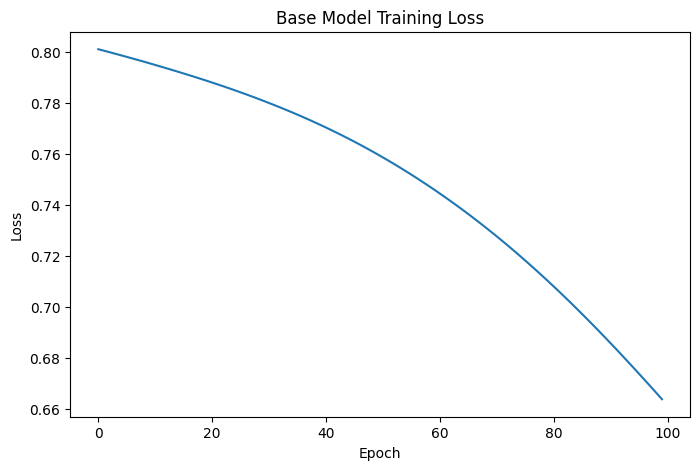

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(base_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Base Model Training Loss")
plt.show()

In [41]:
base_model.eval()

with torch.no_grad():
    y_test_pred = base_model(X_test_tensor)
    y_test_pred_class = (y_test_pred >= 0.5).float()
    
    accuracy = (y_test_pred_class == y_test_tensor).float().mean()
    
print(f"Base Model Accuracy: {accuracy.item():.4f}")

Base Model Accuracy: 0.5858


In [42]:
l2_model = BaseNeuralNetwork(input_size)

print(l2_model)

BaseNeuralNetwork(
  (hidden1): Linear(in_features=7, out_features=16, bias=True)
  (hidden2): Linear(in_features=16, out_features=4, bias=True)
  (output): Linear(in_features=4, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


In [43]:
weight_decay=0.01

In [44]:
l2_criterion = nn.BCELoss()

l2_optimizer = optim.Adam(
    l2_model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

In [45]:
epochs = 100
l2_losses = []

for epoch in range(epochs):
    l2_model.train()
    
    y_pred_l2 = l2_model(X_train_tensor)
    
    l2_loss = l2_criterion(y_pred_l2, y_train_tensor)
    
    l2_optimizer.zero_grad()
    l2_loss.backward()
    l2_optimizer.step()
    
    l2_losses.append(l2_loss.item())
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], L2 Loss: {l2_loss.item():.4f}")

Epoch [10/100], L2 Loss: 0.6445
Epoch [20/100], L2 Loss: 0.6416
Epoch [30/100], L2 Loss: 0.6385
Epoch [40/100], L2 Loss: 0.6351
Epoch [50/100], L2 Loss: 0.6313
Epoch [60/100], L2 Loss: 0.6271
Epoch [70/100], L2 Loss: 0.6225
Epoch [80/100], L2 Loss: 0.6175
Epoch [90/100], L2 Loss: 0.6122
Epoch [100/100], L2 Loss: 0.6064


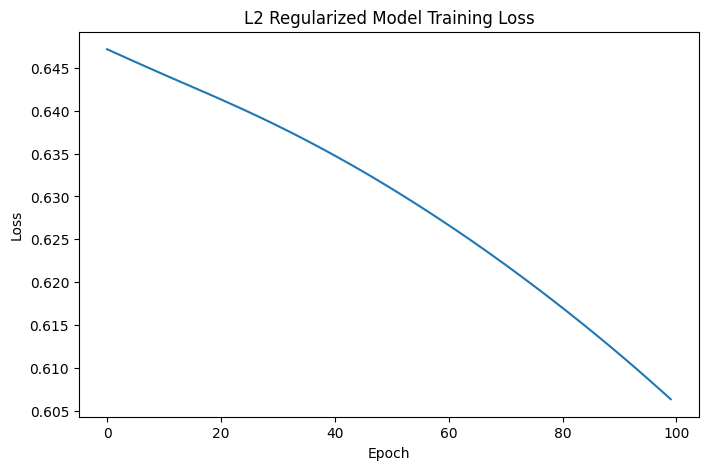

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(l2_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L2 Regularized Model Training Loss")
plt.show()

In [47]:
l2_model.eval()

with torch.no_grad():
    y_test_pred_l2 = l2_model(X_test_tensor)
    y_test_pred_l2_class = (y_test_pred_l2 >= 0.5).float()
    
    l2_accuracy = (y_test_pred_l2_class == y_test_tensor).float().mean()
    
print(f"L2 Model Accuracy: {l2_accuracy.item():.4f}")

L2 Model Accuracy: 0.6817


In [48]:
base_model.eval()
l2_model.eval()

with torch.no_grad():
    base_probs = base_model(X_test_tensor).cpu().numpy().ravel()
    l2_probs = l2_model(X_test_tensor).cpu().numpy().ravel()
    y_true = y_test_tensor.cpu().numpy().ravel()

In [49]:
base_fpr, base_tpr, base_thresholds = roc_curve(y_true, base_probs)
l2_fpr, l2_tpr, l2_thresholds = roc_curve(y_true, l2_probs)

base_auc = auc(base_fpr, base_tpr)
l2_auc = auc(l2_fpr, l2_tpr)

print(f"Base Model AUC: {base_auc:.4f}")
print(f"L2 Model AUC: {l2_auc:.4f}")

Base Model AUC: 0.6545
L2 Model AUC: 0.7585


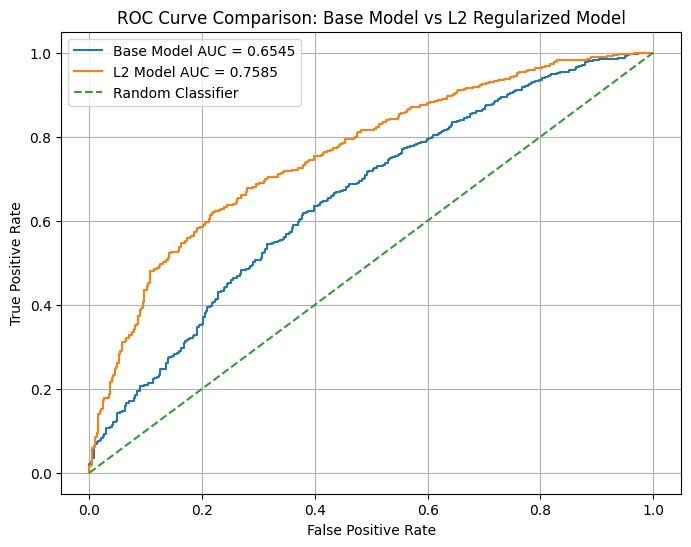

In [50]:
plt.figure(figsize=(8, 6))

plt.plot(base_fpr, base_tpr, label=f"Base Model AUC = {base_auc:.4f}")
plt.plot(l2_fpr, l2_tpr, label=f"L2 Model AUC = {l2_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Base Model vs L2 Regularized Model")
plt.legend()
plt.grid(True)
plt.show()

In [51]:
results = pd.DataFrame({
    "Model": ["Base Neural Network", "L2 Regularized Neural Network"],
    "AUC Score": [base_auc, l2_auc]
})

results

,Model,AUC Score
0,Base Neural Network,0.654505
1,L2 Regularized Neural Network,0.758506
